# Batch VSR E0-E4

Notebook comparativo para cerrar la verificacion VM de los experimentos E0-E4. No entrena modelos, no crea VM y no corre GCP; solo lee configs, manifests y resultados parseados.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from evaluation.src.batch_vsr_notebook import (
    cargar_configs,
    comparar_resultados,
    preprocessing_smoke,
    resultados,
    tamanos_experimentos,
    transcript_asr2,
    transcript_candidates,
    transcript_changes,
    transcript_disagreement,
    transcript_policy,
    transcript_summary,
)

pd.set_option("display.max_colwidth", 140)


## Matriz E0-E4

Revisiones complementarias: `../cleaning/visual_quality/notebooks/08_transcript_cleaning_review.ipynb` para cambios/candidatos de transcripts y `../preprocessing/notebooks/09_preprocessing_variant_review.ipynb` para smoke/previews de `lower_face_resized96`.

In [2]:
configs = cargar_configs()
configs[["experiment", "status", "visual_cleaning", "transcript_variant", "preprocessing_variant", "blocked_reason"]]

,experiment,status,visual_cleaning,transcript_variant,preprocessing_variant,blocked_reason
0,E0_baseline_original,ready,none,current,current,
1,E1_visual_cleaned,ready,conservative,current,current,
2,E2_transcript_cleaned_stronger,ready,none,transcript_cleaned_stronger,current,
3,E3_preprocessing_variant,ready,none,current,lower_face_resized96,
4,E4_all_combined,ready,conservative,transcript_cleaned_stronger,lower_face_resized96,


In [3]:
tamanos_experimentos(configs)

,experiment,train,val,test
0,E0_baseline_original,4826,466,658
1,E1_visual_cleaned,4623,466,658
2,E2_transcript_cleaned_stronger,4692,466,658
3,E3_preprocessing_variant,4826,466,658
4,E4_all_combined,4500,466,658


## Transcript cleaning

In [4]:
changes = transcript_changes()
candidates = transcript_candidates()
policy = transcript_policy()
asr2 = transcript_asr2()
disagreement = transcript_disagreement()
display(transcript_summary(changes, candidates, policy, asr2, disagreement))
if changes.empty:
    display(Markdown("**Pendiente:** no existe `transcript_cleaning_changes.csv`."))
else:
    display(changes[changes["changed"].astype(str).str.lower() == "true"].head(10))
if not disagreement.empty:
    display(disagreement.groupby("disagreement_level").size().rename("clips").reset_index())

,transcripts,changed,unchanged,asr2_ok,disagreement_high,replacement_candidates,auto_replacements,questionable,bad_candidate,decision
0,5950,52,5898,5950,192,2194,0,1978,192,READY_FOR_VM


,source_id,clip,original_path,cleaned_path,original_text,asr2_text,cleaned_text,changed,change_type,evidence,confidence,auto_applied,asr_disagreement_level
12,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0013,/home/bianc/labios-argentos/data/clips/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0013.txt,vsr/evaluation/outputs/batch_vsr/transcripts_cleaned_stronger/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0013.txt,tengo varios amigos que viven en montreal especialmente en montreal especialmente durante el verano en montreal,tengo varios amigos que viven en Montreal especialmente durante el verano en Montreal,tengo varios amigos que viven en montreal especialmente en montreal especialmente durante el verano en montreal,True,space_normalization,espacios multiples/strip,high,True,low
69,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0070,/home/bianc/labios-argentos/data/clips/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0070.txt,vsr/evaluation/outputs/batch_vsr/transcripts_cleaned_stronger/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0070.txt,que lindo verte aca ah leo le respondo a esta pregunta a sebastian aguero,Qué lindo verte acá. Le respondo a esta pregunta a Sebastián Agüero.,que lindo verte aca ah leo le respondo a esta pregunta a sebastian aguero,True,space_normalization,espacios multiples/strip,high,True,medium
398,ME ACUSARON DE BRUJA Y ME TUVE QUE IR DEL PUEBLO -,clip_0286,/home/bianc/labios-argentos/data/clips/ME ACUSARON DE BRUJA Y ME TUVE QUE IR DEL PUEBLO -/clip_0286.txt,vsr/evaluation/outputs/batch_vsr/transcripts_cleaned_stronger/ME ACUSARON DE BRUJA Y ME TUVE QUE IR DEL PUEBLO -/clip_0286.txt,yo marcela tauro todo jugo jugo con esa carita,"yo, Marcela Tauro todos juntos, así con esa carita",yo marcela tauro todo jugo jugo con esa carita,True,space_normalization,espacios multiples/strip,high,True,medium
492,ME ACUSARON DE BRUJA Y ME TUVE QUE IR DEL PUEBLO -,clip_0380,/home/bianc/labios-argentos/data/clips/ME ACUSARON DE BRUJA Y ME TUVE QUE IR DEL PUEBLO -/clip_0380.txt,vsr/evaluation/outputs/batch_vsr/transcripts_cleaned_stronger/ME ACUSARON DE BRUJA Y ME TUVE QUE IR DEL PUEBLO -/clip_0380.txt,claro esta tu vida vieja y enterrada tus ancestros te la rebaja,"Claro, está tu vieja ahí enterrada, tus ancestros, te la rebaja.",claro esta tu vida vieja y enterrada tus ancestros te la rebaja,True,space_normalization,espacios multiples/strip,high,True,medium
832,ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1,clip_0191,/home/bianc/labios-argentos/data/clips/ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1/clip_0191.txt,vsr/evaluation/outputs/batch_vsr/transcripts_cleaned_stronger/ANÉCDOTA VIAJE MUNDIAL BRASIL 2014 parte 1/clip_0191.txt,no se fala fala no se no se no digo amigo en que momento entramos a brasil,"y no se... Fala, José. Va a llenar. Digo, amigo, ¿en qué momento entramos a Brasil?",no se fala fala no se no se no digo amigo en que momento entramos a brasil,True,space_normalization,espacios multiples/strip,high,True,high
1014,"AZZARO REACCIÓN - RIVER, A LA FINAL LE GANÓ 1-0 A",clip_0056,"/home/bianc/labios-argentos/data/clips/AZZARO REACCIÓN - RIVER, A LA FINAL LE GANÓ 1-0 A/clip_0056.txt","vsr/evaluation/outputs/batch_vsr/transcripts_cleaned_stronger/AZZARO REACCIÓN - RIVER, A LA FINAL LE GANÓ 1-0 A/clip_0056.txt",es muy dificil es mucha ventaja es mucha ventaja lo del arbitro fue realmente impresentable en esa decision,es mucha ventaja es mucha ventaja lo del árbitro fue realmente impresentable en esa decisión,es muy dificil es mucha ventaja es mucha ventaja lo del arbitro fue realmente impresentable en esa decision,True,space_normalization,espacios multiples/strip,high,True,low
1113,"AZZARO REACCIÓN - RIVER, A LA FINAL LE GANÓ 1-0 A",clip_0158,"/home/bianc/labios-argentos/data/clips/AZZARO REACCIÓN - RIVER, A LA FINAL LE GANÓ 1-0 A/clip_0158.txt","vsr/evaluation/outputs/batch_vsr/transcripts_cleaned_stronger/AZZARO REACCIÓN - RIVER, A LA FINAL LE GANÓ 1-0 A/clip_0158.txt",

,disagreement_level,clips
0,high,192
1,low,3784
2,medium,1974


## Preprocessing smoke

In [5]:
smoke = preprocessing_smoke()
if smoke.empty:
    display(Markdown("**Pendiente:** no existe manifest de smoke de preprocessing."))
else:
    display(smoke)

,source_id,clip,original_roi_path,variant_roi_path,variant,shape,dtype,status,reason
0,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0001,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0001.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0001.npz,lower_face_resized96,112x96x96,uint8,ok,NaN
1,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0002,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0002.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0002.npz,lower_face_resized96,81x96x96,uint8,ok,NaN
2,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0003,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0003.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0003.npz,lower_face_resized96,147x96x96,uint8,ok,NaN
3,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0004,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0004.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0004.npz,lower_face_resized96,139x96x96,uint8,ok,NaN
4,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0005,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0005.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0005.npz,lower_face_resized96,137x96x96,uint8,ok,NaN
5,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0006,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0006.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0006.npz,lower_face_resized96,158x96x96,uint8,ok,NaN
6,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0007,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0007.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0007.npz,lower_face_resized96,242x96x96,uint8,ok,NaN
7,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0008,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0008.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0008.npz,lower_face_resized96,154x96x96,uint8,ok,NaN
8,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0009,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0009.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0009.npz,lower_face_resized96,160x96x96,uint8,ok,NaN
9,LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91,clip_0010,data/processed/lip_rois/LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91/clip_0010.npz,evaluation\outputs\batch_vsr\preprocessing_variant_smoke\LE DIJE QUE SOY ARGENTINO - Story Time - CAP 91\clip_0010.npz,lower_face_resized96,220x96x96,uint8,ok,NaN


## Resultados VSR comparativos

Compara `vsr/evaluation/outputs/batch_vsr/results/summary.csv` para `E0_baseline_original`, `E1_visual_cleaned`, `E2_transcript_cleaned_stronger`, `E3_preprocessing_variant` y `E4_all_combined`. La corrida registrada es un gate de verificacion finito, no una corrida de convergencia final.


In [6]:
res = resultados()
if res.empty:
    display(Markdown("**Pendiente de VM:** todavia no hay resultados parseados."))
else:
    display(Markdown("**Fuente:** `vsr/evaluation/outputs/batch_vsr/results/summary.csv`"))
    display(res)

    comparacion = comparar_resultados(res)
    display(Markdown("### Ranking y delta contra E0"))
    display(comparacion)

    if not comparacion.empty and "E0_baseline_original" in set(comparacion["experiment"]):
        mejor = comparacion.sort_values(["wer", "cer"]).iloc[0]
        e0 = comparacion[comparacion["experiment"].eq("E0_baseline_original")].iloc[0]
        mejoras = comparacion[comparacion["delta_wer_vs_e0"].lt(0)]["experiment"].tolist()
        empeoras = comparacion[comparacion["delta_wer_vs_e0"].gt(0)]["experiment"].tolist()
        display(
            Markdown(
                "\n".join(
                    [
                        f"**Mejor WER:** `{mejor['experiment']}` con WER `{mejor['wer']:.6f}` y CER `{mejor['cer']:.6f}`.",
                        f"**Baseline E0:** WER `{e0['wer']:.6f}` y CER `{e0['cer']:.6f}`.",
                        f"**Mejoras vs E0 por WER:** {mejoras if mejoras else 'ninguna'}.",
                        f"**Empeoran vs E0 por WER:** {empeoras if empeoras else 'ninguna'}.",
                    ]
                )
            )
        )


**Fuente:** `vsr/evaluation/outputs/batch_vsr/results/summary.csv`

,experiment,status,rows,wer,cer,reason,output
0,E0_baseline_original,parsed,60,0.790218,0.482433,NaN,vsr/evaluation/outputs/batch_vsr/results/E0_baseline_original.csv
1,E1_visual_cleaned,parsed,60,0.796308,0.483526,NaN,vsr/evaluation/outputs/batch_vsr/results/E1_visual_cleaned.csv
2,E2_transcript_cleaned_stronger,parsed,60,0.757031,0.463850,NaN,vsr/evaluation/outputs/batch_vsr/results/E2_transcript_cleaned_stronger.csv
3,E3_preprocessing_variant,parsed,60,0.792764,0.492735,NaN,vsr/evaluation/outputs/batch_vsr/results/E3_preprocessing_variant.csv
4,E4_all_combined,parsed,60,0.791125,0.506258,NaN,vsr/evaluation/outputs/batch_vsr/results/E4_all_combined.csv


### Ranking y delta contra E0

,experiment,rows,wer,cer,delta_wer_vs_e0,delta_cer_vs_e0,rank_wer,interpretacion,output
2,E2_transcript_cleaned_stronger,60,0.757031,0.463850,-0.033187,-0.018583,1,mejora_vs_e0,vsr/evaluation/outputs/batch_vsr/results/E2_transcript_cleaned_stronger.csv
0,E0_baseline_original,60,0.790218,0.482433,0.000000,0.000000,2,baseline,vsr/evaluation/outputs/batch_vsr/results/E0_baseline_original.csv
4,E4_all_combined,60,0.791125,0.506258,0.000906,0.023825,3,empeora_vs_e0,vsr/evaluation/outputs/batch_vsr/results/E4_all_combined.csv
3,E3_preprocessing_variant,60,0.792764,0.492735,0.002546,0.010302,4,empeora_vs_e0,vsr/evaluation/outputs/batch_vsr/results/E3_preprocessing_variant.csv
1,E1_visual_cleaned,60,0.796308,0.483526,0.006090,0.001093,5,empeora_vs_e0,vsr/evaluation/outputs/batch_vsr/results/E1_visual_cleaned.csv


**Mejor WER:** `E2_transcript_cleaned_stronger` con WER `0.757031` y CER `0.463850`.
**Baseline E0:** WER `0.790218` y CER `0.482433`.
**Mejoras vs E0 por WER:** ['E2_transcript_cleaned_stronger'].
**Empeoran vs E0 por WER:** ['E4_all_combined', 'E3_preprocessing_variant', 'E1_visual_cleaned'].

## Figuras para informe

Graficos embebidos del gate VM: comparacion E0-E4 y foco en la mejora de transcript cleaning contra original.


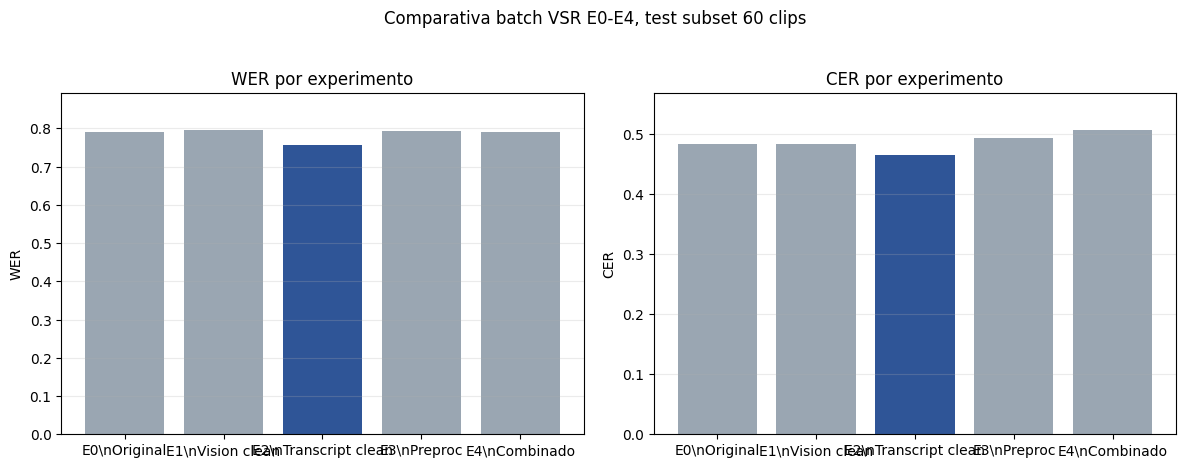

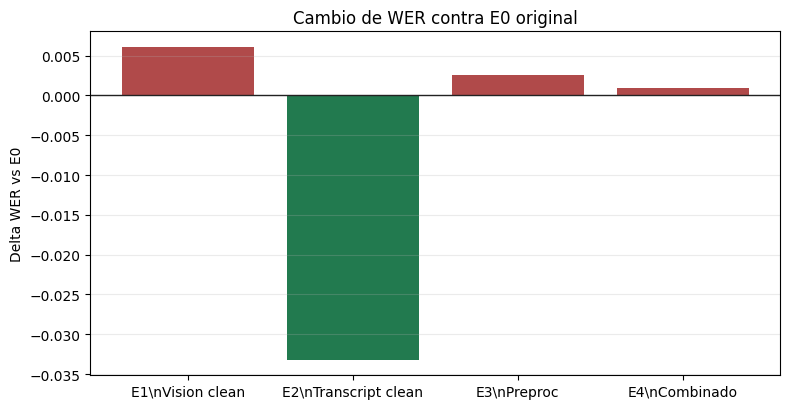

**Figura clave:** E2 transcript cleaning baja WER `0.033187` y CER `0.018583` contra E0 en este gate.

In [7]:
res = resultados()
comparacion = comparar_resultados(res)
if comparacion.empty:
    display(Markdown("**Pendiente:** no hay resultados para graficar."))
else:
    labels = {
        "E0_baseline_original": "E0\\nOriginal",
        "E1_visual_cleaned": "E1\\nVision clean",
        "E2_transcript_cleaned_stronger": "E2\\nTranscript clean",
        "E3_preprocessing_variant": "E3\\nPreproc",
        "E4_all_combined": "E4\\nCombinado",
    }
    plot_df = comparacion.sort_values("experiment").copy()
    plot_df["label"] = plot_df["experiment"].map(labels).fillna(plot_df["experiment"])
    colors = ["#2f5597" if exp == "E2_transcript_cleaned_stronger" else "#9aa6b2" for exp in plot_df["experiment"]]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(plot_df["label"], plot_df["wer"], color=colors)
    axes[0].set_title("WER por experimento")
    axes[0].set_ylabel("WER")
    axes[0].set_ylim(0, max(plot_df["wer"]) * 1.12)
    axes[0].grid(axis="y", alpha=0.25)
    for tick in axes[0].get_xticklabels():
        tick.set_rotation(0)

    axes[1].bar(plot_df["label"], plot_df["cer"], color=colors)
    axes[1].set_title("CER por experimento")
    axes[1].set_ylabel("CER")
    axes[1].set_ylim(0, max(plot_df["cer"]) * 1.12)
    axes[1].grid(axis="y", alpha=0.25)
    for tick in axes[1].get_xticklabels():
        tick.set_rotation(0)

    fig.suptitle("Comparativa batch VSR E0-E4, test subset 60 clips", y=1.03)
    fig.tight_layout()
    plt.show()

    delta_df = plot_df[plot_df["experiment"].ne("E0_baseline_original")].copy()
    delta_colors = ["#227a4f" if value < 0 else "#b04a4a" for value in delta_df["delta_wer_vs_e0"]]
    fig, ax = plt.subplots(figsize=(8, 4.2))
    ax.axhline(0, color="#222222", linewidth=1)
    ax.bar(delta_df["label"], delta_df["delta_wer_vs_e0"], color=delta_colors)
    ax.set_title("Cambio de WER contra E0 original")
    ax.set_ylabel("Delta WER vs E0")
    ax.grid(axis="y", alpha=0.25)
    for tick in ax.get_xticklabels():
        tick.set_rotation(0)
    fig.tight_layout()
    plt.show()

    e2 = comparacion[comparacion["experiment"].eq("E2_transcript_cleaned_stronger")].iloc[0]
    display(
        Markdown(
            f"**Figura clave:** E2 transcript cleaning baja WER `{abs(e2['delta_wer_vs_e0']):.6f}` "
            f"y CER `{abs(e2['delta_cer_vs_e0']):.6f}` contra E0 en este gate."
        )
    )


In [8]:
ready = configs[configs["status"] == "ready"]["experiment"].tolist()
after = configs[configs["status"] == "ready_after_generation"]["experiment"].tolist()
blocked = configs[configs["status"].astype(str).str.contains("blocked", case=False, na=False)]["experiment"].tolist()
low_impact = configs[configs["status"].astype(str).str.contains("low_impact", case=False, na=False)]["experiment"].tolist()
msg = (
    f"**Ready:** {ready}  " + "\n"
    f"**Ready after generation:** {after}  " + "\n"
    f"**Blocked:** {blocked}  " + "\n"
    f"**Low impact:** {low_impact}"
)
display(Markdown(msg))

**Ready:** ['E0_baseline_original', 'E1_visual_cleaned', 'E2_transcript_cleaned_stronger', 'E3_preprocessing_variant', 'E4_all_combined']  
**Ready after generation:** []  
**Blocked:** []  
**Low impact:** []